In [1]:
import numpy as np 
import pandas as pd
import pickle
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path 
import re 
# get utils for thresholds
from src import util_analysis 
from src import util_process_prolific as util_process
import importlib
from tqdm.auto import tqdm
import multiprocessing as mp

/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/scipy/__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [39]:
parent_dir = Path("/om/user/imgriff/datasets/human_word_rec_SWC_2024/")
manifest = pd.read_pickle(parent_dir / "full_cue_target_distractor_df_w_meta_paths.pdpkl")

## Load participant data and meta files 

In [40]:
### Load in experiment manifests with full transcripts
path_to_manifest = Path('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta_transcripts.pdpkl')
df_w_transcripts = pd.read_pickle(path_to_manifest)

# unpack distractor words to individual columns

dist_1_word, dist_2_word = zip(*df_w_transcripts.distractor_word.apply(util_process.unpack_dist_words))

df_w_transcripts['distractor_1_word'] = dist_1_word
df_w_transcripts['distractor_2_word'] = dist_2_word
df_w_transcripts['targ_src_stem'] = df_w_transcripts.excerpt_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_1_src_stem'] = df_w_transcripts.excerpt_distractor_1_src_fn.apply(util_process.slice_transcript_path)
df_w_transcripts['dist_2_src_stem'] = df_w_transcripts.excerpt_distractor_2_src_fn.apply(util_process.slice_transcript_path)


In [41]:
def get_target_transcript(fname):
    return df_w_transcripts.loc[df_w_transcripts['targ_src_stem'].eq(fname), 'target_transcripts'].values[0]

def get_distractor_tscript(fname):
    if df_w_transcripts['dist_1_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_1_src_stem'].eq(fname), 'distractor_1_transcripts'].values[0]
    elif df_w_transcripts['dist_2_src_stem'].eq(fname).any():
        tscript = df_w_transcripts.loc[df_w_transcripts['dist_2_src_stem'].eq(fname), 'distractor_2_transcripts'].values[0]
    return tscript

In [42]:
importlib.reload(util_process)

path_to_parts = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/thresholds_v02')

part_results = sorted(list(path_to_parts.glob("*.csv")))

path_to_meta_data = Path('/mindhive/mcdermott/www/imgriff/part_data/binaural_cocktail_party/speaker_array_manifests/thresholds_v02/')
meta_files = sorted(list(path_to_meta_data.glob("*meta.pkl")))

# meta_files
manifest_dict = {}
for meta_file in meta_files:
    if 'pilot' in meta_file.parent.stem:
        part_name = "pilot_" + "_".join(meta_file.stem.split('_')[:2])

    else:
        part_name = "_".join(meta_file.stem.split('_')[:2])
    manifest_dict[part_name] = meta_file


dfs = []
for result_file in part_results:
    part_name = result_file.stem
    part_ix = int(re.search(r'(\d+)', part_name).group())
    if part_ix > 33:
        continue
    if any(pilot_part_ix == part_ix for pilot_part_ix in [34, 35]):
        continue 

    # remove space 

    if 'pilot' in result_file.parent.stem:
        part_name = "pilot_" + "_".join(result_file.stem.split('_')[:2])
    if ' ' in part_name:
        part_name = part_name.split(' ')[0]
    # get digits in string pattern participant_xxx_ or participant_XXX. 
    part_ix = int(re.search(r'\d+', part_name).group())
    part_name_str = f"participant_{part_ix:03d}"
    manifest_file = manifest_dict[part_name_str]
    part_df = util_process.get_part_df(result_file)
    manifest_df = util_process.get_manifest_df(manifest_file)
    # merge on shared trial_index
    part_df = pd.merge(part_df[['trial_num', 'response', 'correct_response', 'correct']],
            manifest_df, left_on='trial_num', right_on='trial_num', how='left')
    part_df['participant'] = part_name_str
    dfs.append(part_df)

results_df = pd.concat(dfs, ignore_index=True)

## add transcripts for scoring 
results_df['dist_1_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_1_fn.to_list()]
results_df['dist_2_transcripts'] = [util_process.get_distractor_tscript(fname, df_w_transcripts) for fname in results_df.distractor_2_fn.to_list()]
results_df['target_transcripts'] = [util_process.get_target_transcript(fname, df_w_transcripts) for fname in results_df.src_fn.to_list()]

cols_to_score = ['response', 'target_word', 'distractor_1_word', 'distractor_2_word', 'target_transcripts', 'dist_1_transcripts', 'dist_2_transcripts']

## add confusions 
correct = []
confusions = []
for response, target_word, distractor_1_word, distractor_2_word, target_transcripts, dist_1_transcripts, dist_2_transcripts in results_df[cols_to_score].to_numpy():
    correct.append(int(response == target_word or response in target_transcripts))
    confusions.append(int(response in dist_1_transcripts or response in dist_2_transcripts or response in [distractor_1_word, distractor_2_word]))

results_df['correct'] = correct
results_df['confusions'] = confusions




## Group data for plots and fitler bad participants

In [43]:
grouped_part_results = results_df.groupby(['participant', 'target_azim', 'target_elev', 'azim_delta', #'sex_condition',
                                   'elev_delta', 'snr', 'n_distractors',]).agg({'correct':['mean', 'sem'],
                                                                                    'confusions':['mean', 'sem', 'count']}).reset_index()
# flatten multiindex
grouped_part_results.columns = ['_'.join(col).strip() for col in grouped_part_results.columns.values]
# remove trailing underscore
grouped_part_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_part_results.columns.values]


In [44]:
part_perf_avg = grouped_part_results.groupby('participant').correct_mean.mean()
# filter bad participants as those performing below the lower bound (mean - 2 SEM) seen in the online experiments with the same stimuli
cutoff = 0.3
good_parts = part_perf_avg[(part_perf_avg > cutoff)].index


good_part_results = grouped_part_results[grouped_part_results.participant.isin(good_parts)]

print(f"{good_part_results.participant.nunique()} participants above {cutoff} cutoff (out of {part_perf_avg.shape[0]} total)")

33 participants above 0.3 cutoff (out of 33 total)


In [45]:
good_part_results.participant.unique()

array(['participant_001', 'participant_002', 'participant_003',
       'participant_004', 'participant_005', 'participant_006',
       'participant_007', 'participant_008', 'participant_009',
       'participant_010', 'participant_011', 'participant_012',
       'participant_013', 'participant_014', 'participant_015',
       'participant_016', 'participant_017', 'participant_018',
       'participant_019', 'participant_020', 'participant_021',
       'participant_022', 'participant_023', 'participant_024',
       'participant_025', 'participant_026', 'participant_027',
       'participant_028', 'participant_029', 'participant_030',
       'participant_031', 'participant_032', 'participant_033'],
      dtype=object)

In [46]:
good_part_results.groupby('target_elev').participant.nunique()

target_elev
-20    16
 40    17
Name: participant, dtype: int64

### Threshold estimate proceedure

Will be plotting grand average thresholds:
1) average participant data per condition
2) fit thresholds to averaged data
3) bootstrap over participants for error bars 

Actual implementation will use pandas and seaborn to plot average, just need to save individual bootstraps



In [47]:
## Bootstrap over participants to get average and confidence intervals over thresholds

np.random.seed(0)
n_boots = 1_000  ## use 10_000 for final analysis

N = good_part_results.participant.nunique()
thresholds = []
for (dist_azim, dist_elev), data in good_part_results.groupby(['azim_delta', 'elev_delta']):
    # break
    print(N, data.participant.nunique())
    for _ in tqdm(range(n_boots)):
        # sample with replacement
        participant_sample = np.random.choice(data.participant.unique(), size=N, replace=True)
        # stack sampled participants - this makes sure data is duplicated if resampled 
        sample_data = pd.concat([data[data.participant == part] for part in participant_sample], axis=0, ignore_index=True).reset_index()
        # average participants per SNR 
        sample_data = sample_data.groupby(['snr']).agg({'correct_mean':'mean'}).reset_index()
        # fit to participant average
        thresh, poly= util_analysis.estimate_threshold_poly(sample_data.snr.values, sample_data.correct_mean.values, degree=2)
        thresholds.append({
                    # 'target_elev': target_elev,
                    'azim_delta':dist_azim, 'elev_delta':dist_elev,
                    'threshold':thresh})

human_thresh_df = pd.DataFrame(thresholds)


33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

33 33


  0%|          | 0/1000 [00:00<?, ?it/s]

In [48]:
# human_thresh_df_summary = human_thresh_df.groupby(['target_elev', 'elev_delta', 'azim_delta', ]).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
# human_thresh_df_summary.columns = ['target_elev', 'elev_delta', 'azim_delta', 'threshold', 'threshold_std']

# #

human_thresh_df_summary = human_thresh_df.groupby(['elev_delta', 'azim_delta', ]).agg({'threshold':['mean', 'std']}).reset_index()
# # flatten multiindex
human_thresh_df_summary.columns = ['elev_delta', 'azim_delta', 'threshold', 'threshold_std']

# #

Text(0.5, 1.0, 'Huamn thresholds (N=33)')

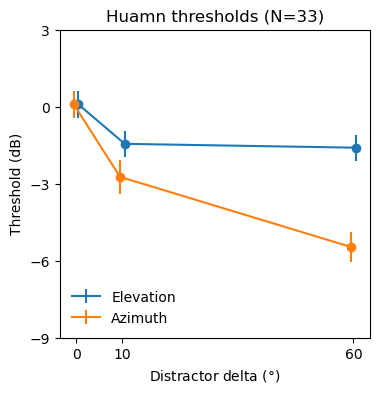

In [49]:
fig, ax = plt.subplots(figsize=(4,4))


elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
ax.errorbar(data=elev_data, x=elev_data.elev_delta + 0.5, y='threshold', yerr='threshold_std', fmt='o-', label='Elevation')
ax.errorbar(data=azim_data, x=azim_data.azim_delta - 0.5, y='threshold', yerr='threshold_std', fmt='o-', label='Azimuth')

ax.legend(loc='lower left', markerscale=0)
ax.get_legend().get_frame().set_linewidth(0.0)

ax.set_xlabel('Distractor delta ($\degree$)')
ax.set_ylabel('Threshold (dB)')
ax.set_xticks([0, 10, 60])
ax.set_yticks(np.arange(-9, 4, 3))
ax.set_title(f"Huamn thresholds (N={N})")

In [51]:
### Compute differences   
# elev diffs: 10 - 0 and 60 - 0 
zero_delta_thresh = human_thresh_df_summary[(human_thresh_df_summary.elev_delta == 0) & (human_thresh_df_summary.azim_delta == 0)].threshold.values
elev_data = human_thresh_df_summary[human_thresh_df_summary.azim_delta == 0]
elev_10_diff = elev_data[elev_data.elev_delta == 10].threshold.values - zero_delta_thresh
elev_60_diff = elev_data[elev_data.elev_delta == 60].threshold.values - zero_delta_thresh

# azim diffs: 10-0 and 60-0
azim_data = human_thresh_df_summary[human_thresh_df_summary.elev_delta == 0]
azim_10_diff = azim_data[azim_data.azim_delta == 10].threshold.values - zero_delta_thresh
azim_60_diff = azim_data[azim_data.azim_delta == 60].threshold.values - zero_delta_thresh

# get true difference of differences 
diff_of_diff_at_10 = azim_10_diff - elev_10_diff
diff_of_diff_at_60 = azim_60_diff - elev_60_diff

print(f"difference of differences at 10 degree delta: {diff_of_diff_at_10.item():.5}")
print(f"difference of differences at 60 degree delta: {diff_of_diff_at_60.item():.5}")

difference of differences at 10 degree delta: -1.2871
difference of differences at 60 degree delta: -3.8698


### Null distribution for significance of difference of differences

In [53]:
## Bootstrap over participants to get average and confidence intervals over thresholds
np.random.seed(0)
n_boots = 10_000  ## Make sure is 10_000 for final analysis

diff_of_diff_10_dist = np.zeros(n_boots)
diff_of_diff_60_dist =  np.zeros(n_boots)

for ix in tqdm(range(n_boots)):
    # permute distractor elevations and azimuths
    permuted = good_part_results.copy()
    # for delta in [10, 60]:
    for part in permuted.participant.unique():
        permuted.loc[permuted.participant == part, 'elev_delta'] = np.random.permutation(permuted[permuted.participant == part].elev_delta)
        permuted.loc[permuted.participant == part, 'azim_delta'] = np.random.permutation(permuted[permuted.participant == part].azim_delta)
    
    # average over particiapnts 
    permuted_summary = permuted.groupby(['snr', 'elev_delta', 'azim_delta' ]).agg({'correct_mean':'mean'}).reset_index()
    
    # only need to do this once per permutation
    zero_delta = permuted_summary[(permuted_summary.elev_delta == 0) & (permuted_summary.azim_delta == 0)]
    thresh_0, _ = util_analysis.estimate_threshold_poly(zero_delta.snr.values, zero_delta.correct_mean.values, degree=2)

    # get elev delta threshold 
    elev_delta = permuted_summary[(permuted_summary.elev_delta == 10)]
    thresh_elev, _ = util_analysis.estimate_threshold_poly(elev_delta.snr.values, elev_delta.correct_mean.values, degree=2)
    # get azim delta threshold
    azim_delta = permuted_summary[permuted_summary.azim_delta == 10]
    thresh_azim, _ = util_analysis.estimate_threshold_poly(azim_delta.snr.values, azim_delta.correct_mean.values, degree=2)
    # compute difference
    elev_diff = thresh_elev - thresh_0
    azim_diff = thresh_azim - thresh_0
    # compute difference of differences
    diff_of_diff = azim_diff - elev_diff
    diff_of_diff_10_dist[ix] = diff_of_diff

    #  repeat for 60 degree delta
    elev_delta = permuted_summary[(permuted_summary.elev_delta == 60)]
    thresh_elev, _ = util_analysis.estimate_threshold_poly(elev_delta.snr.values, elev_delta.correct_mean.values, degree=2)
    # get azim delta threshold
    azim_delta = permuted_summary[permuted_summary.azim_delta == 60]
    thresh_azim, _ = util_analysis.estimate_threshold_poly(azim_delta.snr.values, azim_delta.correct_mean.values, degree=2)
    # compute difference
    elev_diff = thresh_elev - thresh_0
    azim_diff = thresh_azim - thresh_0
    # compute difference of differences
    diff_of_diff = azim_diff - elev_diff
    diff_of_diff_60_dist[ix] = diff_of_diff


  0%|          | 0/10000 [00:00<?, ?it/s]

In [55]:
### Get p value for difference of differences at 10 and 60 degrees

p_10 = (np.abs(diff_of_diff_10_dist) > np.abs(diff_of_diff_at_10)).mean()
p_60 = (np.abs(diff_of_diff_60_dist) > np.abs(diff_of_diff_at_60)).mean()

print(f"p value for difference of differences at 10 degrees: {p_10:.4}")
print(f"p value for difference of differences at 60 degrees: {p_60:.4}")

p value for difference of differences at 10 degrees: 0.0268
p value for difference of differences at 60 degrees: 0.0


## Load model data and meta files

In [ ]:
room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/eval/manifest_room.pdpkl')
# for tuple_ in room_manifest.itertuples():
#     print(tuple_)
#     break
room_material_map = {}
for row in room_manifest.itertuples():
    wall1 = row.material_x0[0].split(',')[0]
    wall2 = row.material_y1[0].split(',')[0]
    if wall1 == wall2:
        wall_str = f"{wall1} walls"
    else:
        wall_str = f"{wall1} and {wall2} walls"

    floor = row.material_z0[0].split(',')[0]
    ceiling = row.material_z1[0].split(',')[0]
    name_str = f"{wall_str} \n {floor} floor \n {ceiling} ceiling"

    if row.index_room in [5, 6]:
        name_str = 'Alternate speaker room'
    if row.index_room in [6, 8]:
        name_str += ' \n head rotated'
    else:
        head_rotated = ''
    if 'Anechoic' in name_str:
        name_str = "Anechoic"
    room_material_map[row.index_room] = name_str
# room_material_map = {row.index_room: f"{row.material_x0[0].split(',')[0]} and \n {row.material_y1[0].split(',')[0]} walls \n {row.material_z0[0].split(',')[0]} floor \n {row.material_z1[0].split(',')[0]} ceiling" for row in room_manifest.itertuples()}
# room_material_map[5] = 'standard speaker room'
room_material_map

{0: 'Anechoic',
 1: 'Wood panelling on glass fiber blanket walls \n Carpet on foam rubber padding floor \n Highly absorptive panels ceiling',
 2: 'Brick walls \n Wood parquet on concrete floor \n Plaster ceiling',
 3: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 4: 'Concrete walls \n Linoleum floor \n Acoustic tiles ceiling',
 5: 'Alternate speaker room',
 6: 'Alternate speaker room \n head rotated',
 7: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling',
 8: 'Fiberglass wall treatment walls \n Linoleum floor \n Acoustic tiles ceiling \n head rotated'}

In [3]:
import pickle 

manifest_path = "binaural_test_manifests/human_array_exmpt_sim_v02_only_human_locs_w_noise_min_reverb_mit_room_v02.pkl"
with open(manifest_path, "rb") as f: 
    manifest = pickle.load(f)
    

In [4]:
manifest_df  = pd.DataFrame(manifest.values())
# manifest_df

In [5]:
# spkr_room_manifest = pd.read_pickle('/om2/user/msaddler/spatial_audio_pipeline/assets/brir/mit_bldg46room1004/manifest_room.pdpkl')
spkr_room_manifest = pd.read_pickle('/om2/user/imgriff/spatial_audio_pipeline/assets/brir/mit_bldg46room1004_min_reverb/manifest_room.pdpkl')

In [6]:

output_paths = list(Path(f"binaural_eval/simulate_2024_human_threshold_experiment_v02/").glob("*/*.pkl"))
stim_manifest_df = pd.read_pickle('/om/user/imgriff/datasets/human_word_rec_SWC_2024/full_cue_target_distractor_df_w_meta.pdpkl')


word_class_map = pickle.load( open("/om2/user/imgriff/datasets/commonvoice_9/en/cv_800_word_label_to_int_dict.pkl", "rb" )) 
ix_to_word = {v:k for k,v in word_class_map.items()}

remap_azim = lambda azim: 360 - azim if azim > 180 else 0 - azim 

results_dfs = []

wanted_models = ['word_task_half_co_loc_v09_gender_bal_4M_w_no_cue_learned_higher_lr_less_dropout',
                #  'word_task_v09_4MGB_ln_first_arch_1',
                # 'word_task_v09_4MGB_ln_first_arch_2',
                # 'word_task_v09_4MGB_ln_first_arch_4',
                # 'word_task_v09_4MGB_ln_first_arch_6',
                # 'word_task_v09_4MGB_ln_first_arch_7',
                # 'word_task_v09_4MGB_ln_first_arch_8',
                # 'word_task_v09_4MGB_ln_first_arch_9',
]

gend_map = {True:'same', False:'different'}

for path in output_paths:
    # if not any([model in path.stem for model in wanted_models]):
    #     continue
    # if not 'v09' in str(path):
    #     continue
    # if 'modulated' in path.stem:
    #     continue 
    # if not 'mitb46' in path.stem:
    #     continue 
    # if 'white_noise' in path.as_posix():
    #     continue
    # if 'texture' in path.as_posix():
    #     continue

    res_dict = pickle.load(open(path, 'rb'))
    to_track = {key:val for key,val in res_dict.items() if key != 'textures'}

    df = pd.DataFrame.from_dict(to_track)
    # break
    df.rename(columns={"results": "accuracy"}, inplace=True)
    df['model'] = path.parent.stem

    df.loc[df.index.values, ['word', 'distractor_word','sex_cond']] = stim_manifest_df.loc[df.stim_ix_list.values, ['word', 'distractor_word','sex_cond']].values
    df['target_word'] = df['true_word_int'].map(ix_to_word)
    df['pred_word'] = df['preds'].map(ix_to_word)
    df['correct'] = (df['true_word_int'] == df['preds']).astype('int')
    df['str_confusions'] = df[['pred_word', 'distractor_word']].apply(lambda x: 1 if x.pred_word in x.distractor_word else 0, axis=1)
    ## Get SNR level from path
    if 'clean' in path.stem:
        snr = 'clean'
    else:
        snr = int(re.search('(-?\d+)_SNR', path.stem).group(0).strip('_SNR'))
    df['snr'] = snr 
    ## Get texture leve lfrom path 
    if "no_texture" in path.stem:
        texture_level = 'no_texture'
    
    else: 
        texture_level = re.search('(-?\d+)dB_bg_texture',path.stem).group(0).split('dB')[0]

    df['texture_level'] = texture_level
    df["target_azim"], df["target_elev"] = path.stem.split('target_loc_')[1].split('_distract_loc_')[0].split('_')
    df["distractor_azim"], df["distractor_elev"] = path.stem.split('_distract_loc_')[1].split('_')[:2]
    # # map azim to 0-180
    df['target_azim'] = df['target_azim'].astype(int).apply(remap_azim)
    df['distractor_azim'] = df['distractor_azim'].astype(int).apply(remap_azim)
    df['target_elev'] = df['target_elev'].astype(int)
    df['distractor_elev'] = df['distractor_elev'].astype(int)
    df['room_ix'] = int(re.search('room(-?\d+)', path.stem).group(0).strip('room'))
    df['room_type'] = re.search('SNR_(.*?)_room', path.stem).group(0).split('SNR_')[-1].split("_room")[0]
    df['n_distractors'] = 1 if '1_distractor' in path.stem else 2
    df['test_set'] = 'all_stim' if 'all_stim' in path.stem else 'subset'
    # if 'white_noise' in path.as_posix():
    #     df['distractor_type'] = 'white_noise'
    # elif 'texture' in path.as_posix():
    #     df['distractor_type'] = 'texture'
    # else:
    # df['distractor_type'] = 'speech'
    results_dfs.append(df)

results = pd.concat(results_dfs)

In [7]:
results.loc[results.room_type.str.contains('eval'), 'room_str'] = results.loc[results.room_type == 'eval', 'room_ix'].map(room_material_map)

results.loc[results.room_type.str.contains('mitb46'), 'room_str'] = 'Normal speaker array'
results.loc[results.room_type.str.contains('mitb46'), 'room_ix'] = 9 # use n from diff room notebook

results.loc[results.room_type.str.contains('reverb'), 'room_str'] = 'Min. reverb speaker array'
results.loc[results.room_type.str.contains('reverb'), 'room_ix'] = 10 # use n from diff room notebook

In [8]:
grouped_model_results = results.groupby(['model', 'target_azim', 'target_elev', 'distractor_azim', 'test_set',  'texture_level',
                                   'distractor_elev', 'sex_cond', 'snr', 'n_distractors', 'room_str']).agg({'accuracy':['mean', 'sem'],
                                                                                                                     'confusions':['mean', 'sem']}).reset_index()
# flatten multiindex
grouped_model_results.columns = ['_'.join(col).strip() for col in grouped_model_results.columns.values]
# remove trailing underscore
grouped_model_results.columns = [col[:-1] if col[-1] == '_' else col for col in grouped_model_results.columns.values]



In [9]:
grouped_model_results['distractor_elev_delta'] = (grouped_model_results['target_elev'] - grouped_model_results['distractor_elev']).abs()

In [10]:
grouped_model_results.texture_level.unique()

array(['40', '45', '50', '55', '60', 'no_texture'], dtype=object)

<Figure size 640x480 with 0 Axes>

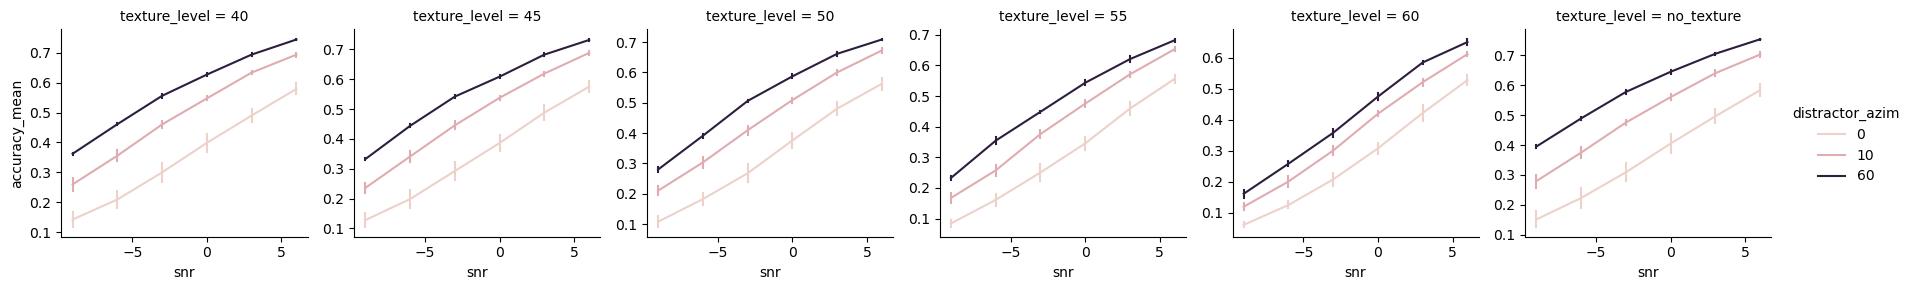

In [11]:
to_plot = grouped_model_results[
                        (grouped_model_results.distractor_elev_delta.eq(0 ))
                            & (grouped_model_results.distractor_azim.abs().isin([0,10, 60])) 
                            ].copy()

to_plot.distractor_azim = to_plot.distractor_azim.abs()                    


azim_thresholds = []
# p0 = [0.0, -4, 4]


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                                x='snr', y='accuracy_mean', hue="distractor_azim",
                                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                                col='texture_level',#  col_order=col_order,
                                # row='room_str',
                                # palette=palette, 
                                errorbar=('se', 1),
                                err_style='bars',
                                height=3, aspect=1)

In [12]:
grouped_model_results['azim_delta'] = (grouped_model_results['distractor_azim'] - grouped_model_results['target_azim']).abs()
grouped_model_results['elev_delta'] = (grouped_model_results['distractor_elev'] - grouped_model_results['target_elev']).abs()

In [15]:
## Fit model thresholds per texture level 
np.random.seed(0)
n_boots = 1_000  ## use 10_000 for final analysis


model_thresholds = []

for (texture_level, dist_azim, dist_elev), data in grouped_model_results.groupby(['texture_level', 'azim_delta', 'elev_delta']):
    results_for_thresh = data.groupby('snr').agg({'accuracy_mean':'mean'}).reset_index()
    thresh, poly = util_analysis.estimate_threshold_poly(results_for_thresh.snr.values, results_for_thresh.accuracy_mean.values, degree=2)
    model_thresholds.append({
                    'texture_level':texture_level, 'azim_delta':dist_azim, 'elev_delta':dist_elev,
                    'threshold':thresh})

model_thresh_df = pd.DataFrame(model_thresholds)

In [16]:
azim_data = to_plot[to_plot.elev_delta == 0]


AttributeError: 'DataFrame' object has no attribute 'elev_delta'

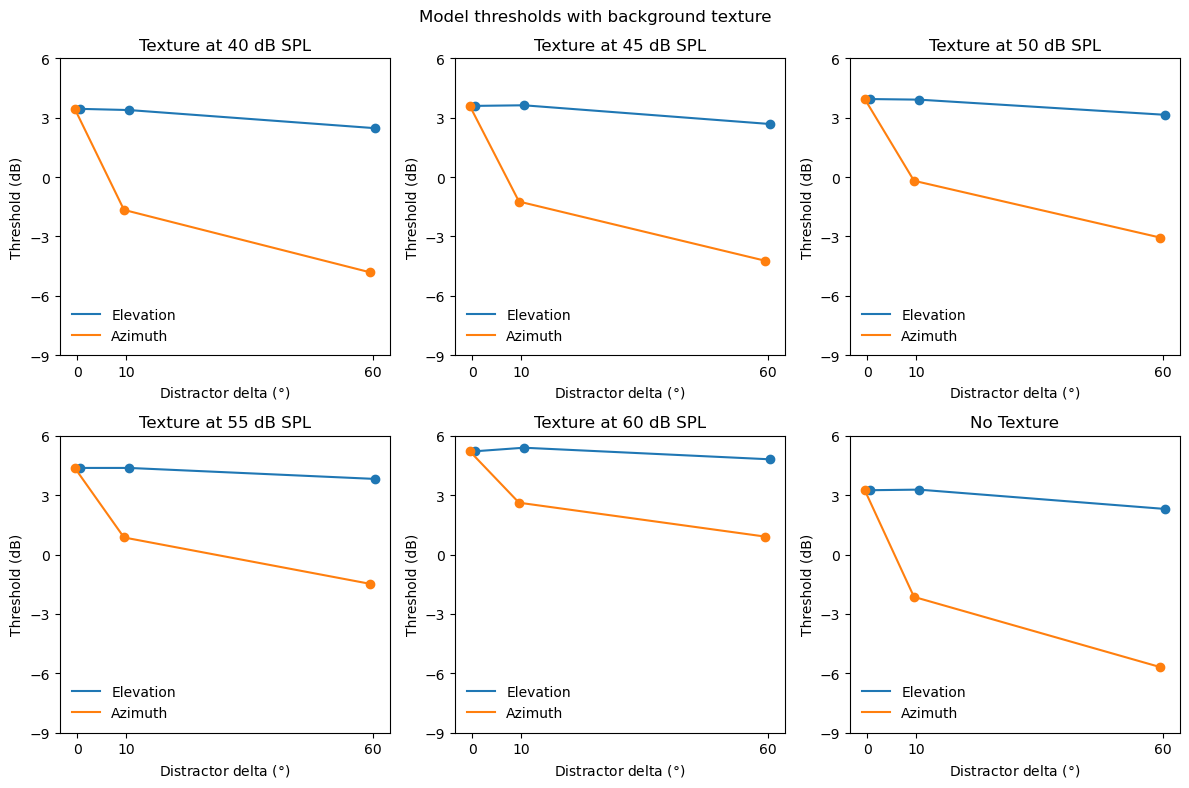

In [19]:
fig, axs = plt.subplots(2,3, figsize=(12,8))
axs = axs.flatten()
for i, txt_lvl in enumerate(model_thresh_df.texture_level.unique()):
    ax = axs[i]
    to_plot = model_thresh_df[model_thresh_df.texture_level == txt_lvl]
    elev_data = to_plot[to_plot.azim_delta == 0]
    azim_data = to_plot[to_plot.elev_delta == 0]
    ax.errorbar(x=elev_data.elev_delta + 0.5, y=elev_data.threshold.values,  fmt='o-', label='Elevation')
    ax.errorbar(x=azim_data.azim_delta - 0.5, y=azim_data.threshold.values,  fmt='o-', label='Azimuth')

    ax.legend(loc='lower left', markerscale=0)
    ax.get_legend().get_frame().set_linewidth(0.0)

    ax.set_xlabel('Distractor delta ($\degree$)')
    ax.set_ylabel('Threshold (dB)')
    ax.set_xticks([0, 10, 60])
    ax.set_yticks(np.arange(-9, 7, 3))
    if txt_lvl == 'no_texture':
        ax.set_title(f"No Texture")
    else:
        ax.set_title(f"Texture at {txt_lvl} dB SPL")
plt.suptitle("Model thresholds with background texture")
plt.tight_layout()

In [30]:
# put humans and model in same dataframe. Change correct to accuracy in column names 
grouped_model_results.rename(columns={'accuracy_mean':'correct_mean', 'accuracy_sem':'correct_sem'}, inplace=True)
grouped_model_results['group'] = 'Model'
N = good_part_results.participant.nunique()
good_part_results['group'] = f'Humans (N={N})'
merged_results = pd.concat([grouped_model_results, good_part_results], ignore_index=True, axis=0)

# N = good_part_results.participant.nunique()
# good_part_results['group'] = f'Humans (N={N})'
# merged_results = pd.concat([grouped_model_results, good_part_results], ignore_index=True, axis=0)



# N = good_part_results.participant.nunique()
# good_part_results['group'] = f'Humans (N={N})'


# merged_good_parts = merged_results[merged_results.participant.isin(good_parts)]

In [31]:
merged_results.group.unique()

array(['Model', 'Humans (N=24)'], dtype=object)

Text(0.5, 1.05, 'Azimuth performance')

<Figure size 640x480 with 0 Axes>

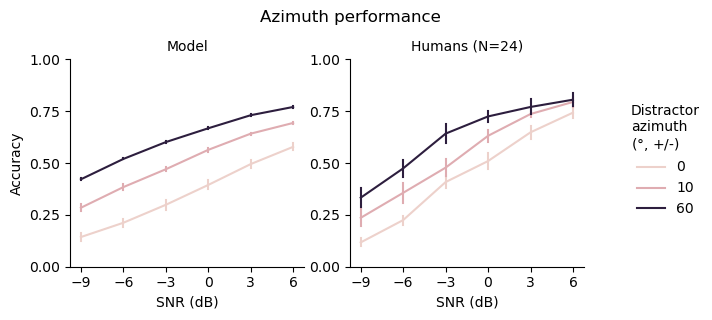

In [32]:


## First, get grand average. Then bootstrap for error 
# sns.set_context('talk')

# avg threshold estimates for 0 and 10 azimuth separation 
to_plot = merged_results[
                    (merged_results.n_distractors == 2)
                        #   & (merged_results.room_str == 'Min. reverb speaker array')
                        & (merged_results.distractor_elev_delta.eq(0 ))
                         & (merged_results.distractor_azim.abs().isin([0,10, 60])) 
                        #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ].copy()

to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='correct_mean', hue="distractor_azim",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='group', 
                # row='room_str',
                # palette=palette, 
                errorbar=('se', 1),
                err_style='bars',
                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nazimuth\n($\degree$, +/-)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
plt.suptitle(f'Azimuth performance', y=1.05)

# plot azim thresholds
# sns.set_style('white')
# fig, axs = plt.subplots(1,2, figsize=(9, 4))
# g = sns.lineplot(data=azim_thresh_df, x='azim', y='threshold', hue='dist_type', style='room', marker='o', ax=axs[0],  legend=False)
# # axs[0].set_title(f'Model azimuth thresholds', y=1.05)
# axs[0].set_title(f'Model azimuth thresholds', y=1.05)

# axs[0].set_xlabel('Distractor azimuth ($\degree$, +/-)')
# axs[0].set_ylabel("Threshold (dB SNR)")
# axs[0].set_ylim(-15,5)
# axs[0].set_xticks(np.arange(0, 31, 10))

# # get srm per model
# for model in azim_thresh_df.model.unique():
#     for dist_type in azim_thresh_df.dist_type.unique():
#         for room_type in azim_thresh_df.room.unique():
#             ixs = (azim_thresh_df.model == model) & (azim_thresh_df.dist_type == dist_type) & (azim_thresh_df.room == room_type)
#             model_data = azim_thresh_df[ixs]
#             azim_thresh_df.loc[ixs, 'srm'] = model_data.threshold - model_data.threshold.max()
# # sns.set_style('white')
# g = sns.lineplot(data=azim_thresh_df, x='azim', y='srm', hue='dist_type', style='room', marker='o', ax=axs[1], legend=True)
# # axs[1].set_title(f'Model azimuth spatial release', y=1.05)
# axs[1].set_xlabel('Distractor azimuth ($\degree$, +/-)')
# axs[1].set_ylabel("Spatial release (dB SNR)")
# axs[1].set_ylim(-15,5)
# axs[1].set_xticks(np.arange(0, 31, 10))

# # adjust w space 
# plt.subplots_adjust(wspace=0.6)
# # adjust legend 
# handles, labels = axs[1].get_legend_handles_labels()
# axs[1].legend(handles=handles, labels=labels, title='Distractor type', loc='center right', fontsize=12, title_fontsize=12, bbox_to_anchor=(2.1, 0.5))



<Figure size 640x480 with 0 Axes>

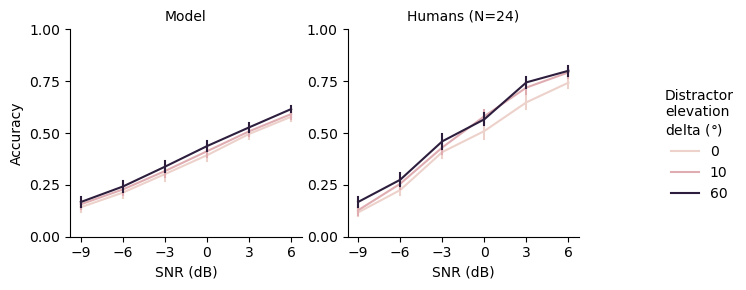

In [39]:
to_plot = merged_results[
                    (merged_results.n_distractors == 2)
                        #   & (merged_results.room_str == 'Min. reverb speaker array')
                        # & (merged_results.distractor_elev_delta.isin([0,10,60]))
                        &	(merged_results.distractor_azim == 0) 
                        &	(merged_results.target_elev != 0) 

                        #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='correct_mean', hue="distractor_elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='group', 
                # row='room_str',
                # palette=palette, 
                errorbar=('se', 1),
                err_style='bars',
                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)

<Figure size 640x480 with 0 Axes>

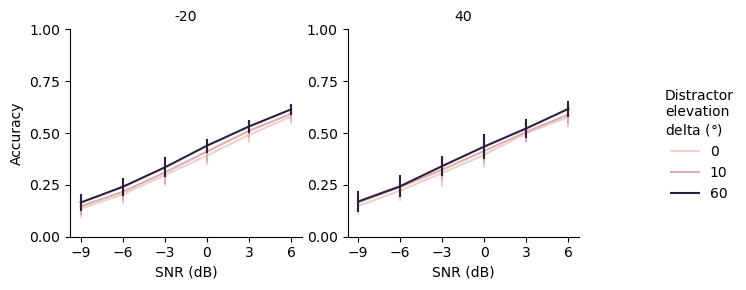

In [40]:
to_plot = merged_results[
                    (merged_results.n_distractors == 2)
                    & (merged_results.group == 'Model')
                        #   & (merged_results.room_str == 'Min. reverb speaker array')
                        # & (merged_results.distractor_elev_delta.isin([0,10,60]))
                    &	(merged_results.distractor_azim == 0) 
                    &	(merged_results.target_elev != 0) 

                        #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='correct_mean', hue="distractor_elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='target_elev', 
                # row='room_str',
                # palette=palette, 
                errorbar=('se', 1),
                err_style='bars',
                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)

<Figure size 640x480 with 0 Axes>

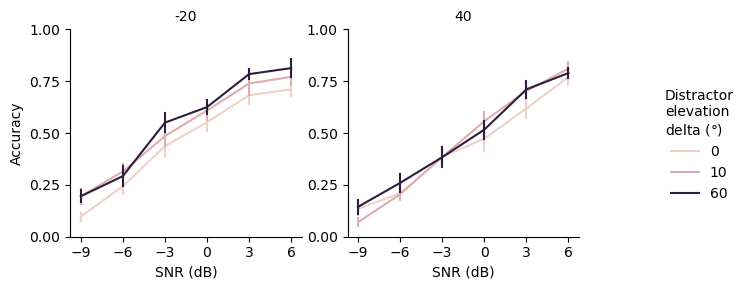

In [35]:
to_plot = merged_results[
                    (merged_results.n_distractors == 2)
                    & (merged_results.group != 'Model')
                        #   & (merged_results.room_str == 'Min. reverb speaker array')
                        # & (merged_results.distractor_elev_delta.isin([0,10,60]))
                        &	(merged_results.distractor_azim == 0) 
                        #   & (merged_results.snr.isin([6,3, 0, -3, -6, -9,]))
                          ].copy()

# to_plot.distractor_azim = to_plot.distractor_azim.abs()                    
# azim_results_for_thresh = to_plot.groupby(['model','room_str', 'distractor_azim', 'distractor_type', 'snr']).agg({'correct_mean':'mean'}).reset_index()



# azim_thresholds = []
# p0 = [0.0, -4, 4]
# for (model, room, dist_type, azim), group in azim_results_for_thresh.groupby(['model', 'room_str', 'distractor_type', 'distractor_azim']): #, 'gender_cond']):
#     thresh, fit_popt, _ = util_analysis.estimate_thresholds(group.snr.values, group.correct_mean.values, bounds_from_data=True)#, p0=p0)
#     if np.isnan(thresh):
#         print(f"Threshold is nan for azim {azim}")
#     azim_thresholds.append({'model': model, "room":room, "dist_type":dist_type, 'azim': azim, 'threshold':thresh}) #  'gender_cond':gend_cond,
    
# azim_thresh_df = pd.DataFrame(azim_thresholds)


plt.figure()
g = sns.relplot(data=to_plot[to_plot.snr.isin([6,3, 0, -3, -6, -9,])],
                x='snr', y='correct_mean', hue="distractor_elev_delta",
                kind='line', legend='full', facet_kws={"sharey":False, "sharex":False},
                col='target_elev', 
                # row='room_str',
                # palette=palette, 
                errorbar=('se', 1),
                err_style='bars',
                height=3, aspect=1)
g.set_axis_labels("SNR (dB)", "Accuracy")
# set legend title 
new_title = 'Distractor\nelevation\ndelta ($\degree$)'
g._legend.set_title(new_title)
# set xticks from -9 to 6
g.set(xticks=np.arange(-9, 7, 3), yticks=[0, 0.25, 0.5, 0.75, 1])
# column titles 
g.set_titles("{col_name}")
# plt.suptitle(f'Model elevation performance', y=1.05)